In [1]:
import xarray as xr

In [2]:
filename = '/home/lacrio/Documents/thermo_eq_test_lev/era5_T2_202002_t_adv_and_grads_lev.nc'
ds = xr.open_dataset(filename) * 3600

filename = '/home/lacrio/Documents/thermo_eq_test_lev/era5_T2_202002_t_adv_and_grads_2m.nc'
ds_2m = xr.open_dataset(filename) * 3600

ds_2m

<xarray.Dataset> Size: 20MB
Dimensions:     (valid_time: 216, latitude: 61, longitude: 75)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 2020-02-01 ... 2020-02-09T23:...
  * latitude    (latitude) float64 488B -70.0 -69.5 -69.0 ... -41.0 -40.5 -40.0
  * longitude   (longitude) float64 600B -85.0 -84.5 -84.0 ... -49.0 -48.5 -48.0
Data variables:
    t_adv       (valid_time, latitude, longitude) float64 8MB 0.0159 ... -0.3567
    tgradx      (valid_time, latitude, longitude) float32 4MB -0.0003698 ... ...
    tgrady      (valid_time, latitude, longitude) float64 8MB 0.0392 ... 0.02061
Attributes:
    history:  Derived with advect_variable_cfd from /home/lacrio/Documents/th...

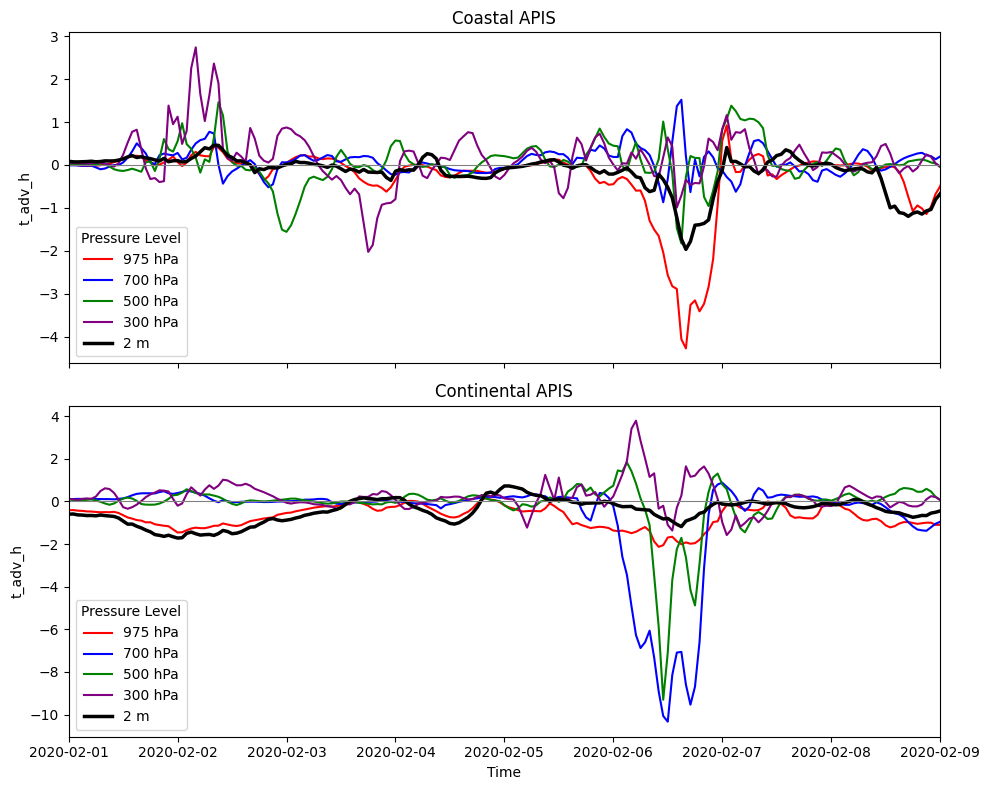

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Coastal point ---
lat1, lon1 = -63.5, -57.0
ds_sel1 = ds.sel(latitude=lat1, longitude=lon1, method='nearest')
da1 = ds_sel1['t_adv_h'].sel(pressure_level=[975, 700, 500, 300])

ds_sel1_2m = ds_2m.sel(latitude=lat1, longitude=lon1, method='nearest')
da1_2m = ds_sel1_2m['t_adv']

# --- Continental point ---
lat2, lon2 = -66.022, -63.877
ds_sel2 = ds.sel(latitude=lat2, longitude=lon2, method='nearest')
da2 = ds_sel2['t_adv_h'].sel(pressure_level=[975, 700, 500, 300])

ds_sel2_2m = ds_2m.sel(latitude=lat2, longitude=lon2, method='nearest')
da2_2m = ds_sel2_2m['t_adv']

# --- Subplots ---
fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)

levels = [975, 700, 500, 300]

color_dict = {
    975: 'red',
    700: 'blue',
    500: 'green',
    300: 'purple'
}

# --- Coastal ---
for p in levels:
    axes[0].plot(
        da1.valid_time,
        da1.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

# ✅ Add 2m line
axes[0].plot(
    da1_2m.valid_time,
    da1_2m,
    color='black',
    linewidth=2.5,
    linestyle='-',
    label='2 m'
)

axes[0].set_title('Coastal APIS')
axes[0].set_ylabel('t_adv_h')
axes[0].legend(title='Pressure Level')

# --- Continental ---
for p in levels:
    axes[1].plot(
        da2.valid_time,
        da2.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

# ✅ Add 2m line
axes[1].plot(
    da2_2m.valid_time,
    da2_2m,
    color='black',
    linewidth=2.5,
    linestyle='-',
    label='2 m'
)

axes[1].set_title('Continental APIS')
axes[1].set_ylabel('t_adv_h')
axes[1].set_xlabel('Time')
axes[1].legend(title='Pressure Level')

# --- Limits ---
for ax in axes:
    ax.set_xlim(pd.to_datetime('2020-02-01'), pd.to_datetime('2020-02-09'))
    ax.axhline(0, color='gray', linewidth=0.8)  # optional but useful

plt.tight_layout()
plt.show()

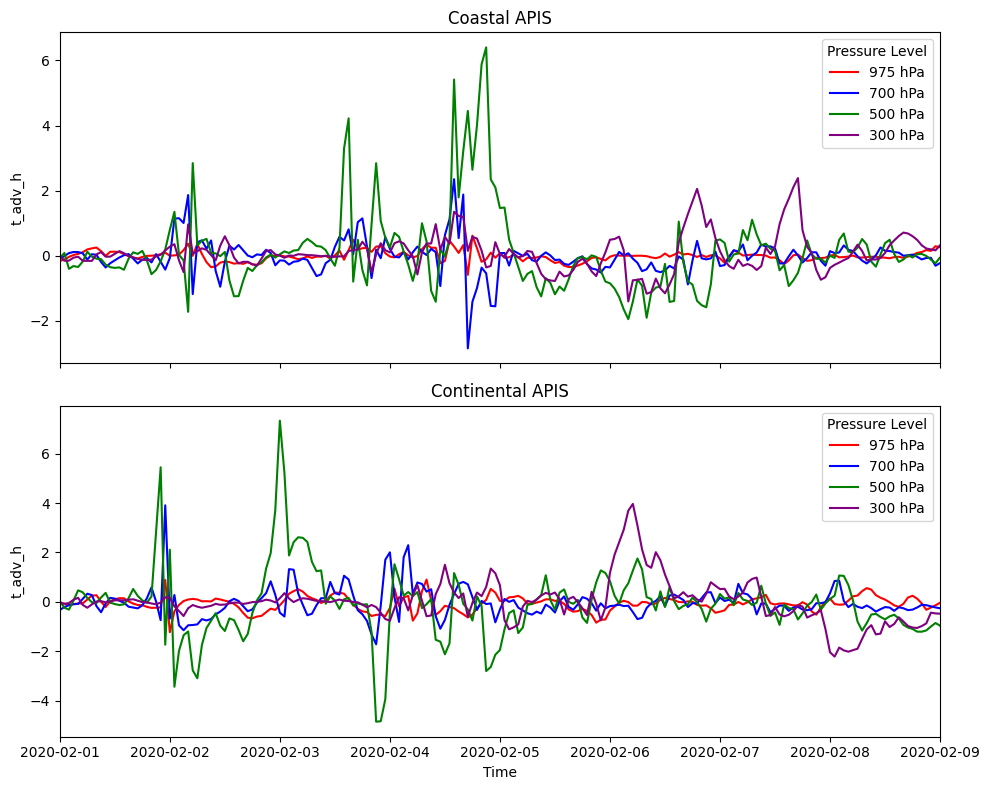

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Coastal point ---
lat1, lon1 = -63.5, -57.0
ds_sel1 = ds.sel(latitude=lat1, longitude=lon1, method='nearest')
da1 = ds_sel1['t_adv_v'].sel(pressure_level=[975, 700, 500, 300])

# --- Continental point ---
lat2, lon2 = -66.022, -63.877
ds_sel2 = ds.sel(latitude=lat2, longitude=lon2, method='nearest')
da2 = ds_sel2['t_adv_v'].sel(pressure_level=[975, 700, 500, 300])

# --- Subplots ---
fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)

levels = [975, 700, 500, 300]

# ✅ Define clear, distinct colors
color_dict = {
    975: 'red',
    700: 'blue',
    500: 'green',
    300: 'purple'
}

# --- Coastal ---
for p in levels:
    axes[0].plot(
        da1.valid_time,
        da1.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

axes[0].set_title('Coastal APIS')
axes[0].set_ylabel('t_adv_h')
axes[0].legend(title='Pressure Level')

# --- Continental ---
for p in levels:
    axes[1].plot(
        da2.valid_time,
        da2.sel(pressure_level=p),
        color=color_dict[p],  # same color = same level
        label=f'{p} hPa'
    )

axes[1].set_title('Continental APIS')
axes[1].set_ylabel('t_adv_h')
axes[1].set_xlabel('Time')
axes[1].legend(title='Pressure Level')

# --- Limits ---
for ax in axes:
    ax.set_xlim(pd.to_datetime('2020-02-01'), pd.to_datetime('2020-02-09'))

plt.tight_layout()
plt.show()

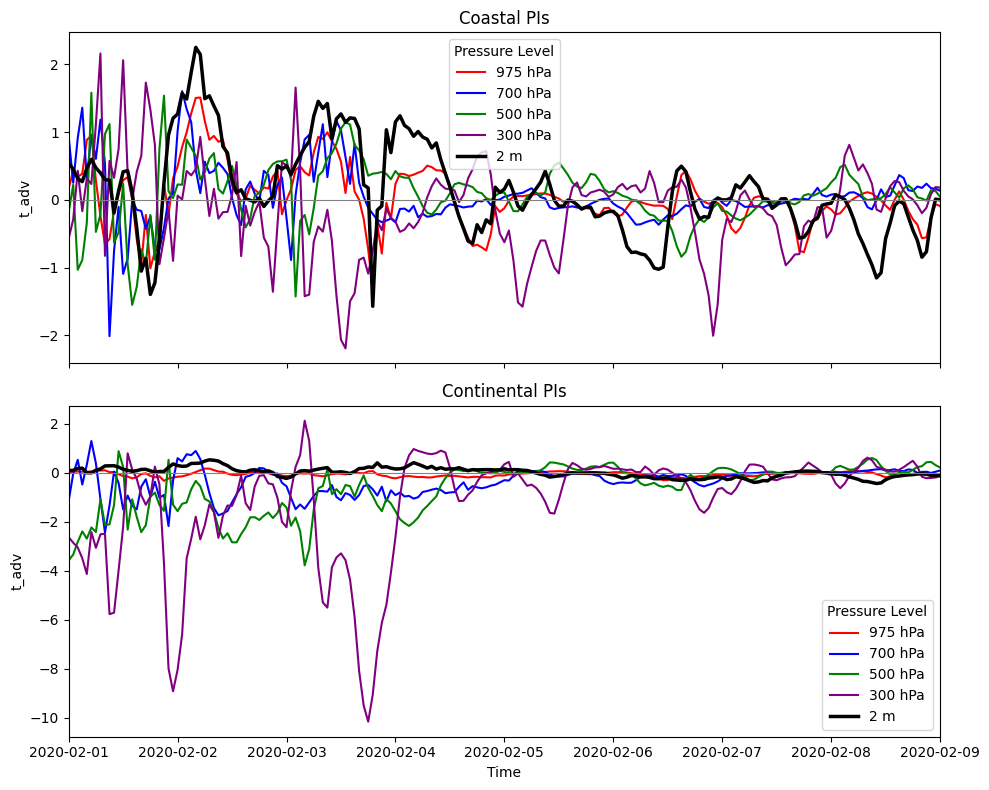

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Coastal point ---
lat1, lon1 = -48.29, -75.50
ds_sel1 = ds.sel(latitude=lat1, longitude=lon1, method='nearest')
da1 = ds_sel1['t_adv_h'].sel(pressure_level=[975, 700, 500, 300])

ds_sel1_2m = ds_2m.sel(latitude=lat1, longitude=lon1, method='nearest')
da1_2m = ds_sel1_2m['t_adv']

# --- Continental point ---
lat2, lon2 = -48.81, -73.51
ds_sel2 = ds.sel(latitude=lat2, longitude=lon2, method='nearest')
da2 = ds_sel2['t_adv_h'].sel(pressure_level=[975, 700, 500, 300])

ds_sel2_2m = ds_2m.sel(latitude=lat2, longitude=lon2, method='nearest')
da2_2m = ds_sel2_2m['t_adv']

# --- Subplots ---
fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)

levels = [975, 700, 500, 300]

color_dict = {
    975: 'red',
    700: 'blue',
    500: 'green',
    300: 'purple'
}

# --- Coastal ---
for p in levels:
    axes[0].plot(
        da1.valid_time,
        da1.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

# ✅ Add 2 m
axes[0].plot(
    da1_2m.valid_time,
    da1_2m,
    color='black',
    linewidth=2.5,
    label='2 m'
)

axes[0].set_title('Coastal PIs')
axes[0].set_ylabel('t_adv')
axes[0].legend(title='Pressure Level')

# --- Continental ---
for p in levels:
    axes[1].plot(
        da2.valid_time,
        da2.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

# ✅ Add 2 m
axes[1].plot(
    da2_2m.valid_time,
    da2_2m,
    color='black',
    linewidth=2.5,
    label='2 m'
)

axes[1].set_title('Continental PIs')
axes[1].set_ylabel('t_adv')
axes[1].set_xlabel('Time')
axes[1].legend(title='Pressure Level')

# --- Limits ---
for ax in axes:
    ax.set_xlim(pd.to_datetime('2020-02-01'), pd.to_datetime('2020-02-09'))
    ax.axhline(0, color='gray', linewidth=0.8)  # optional but useful

plt.tight_layout()
plt.show()

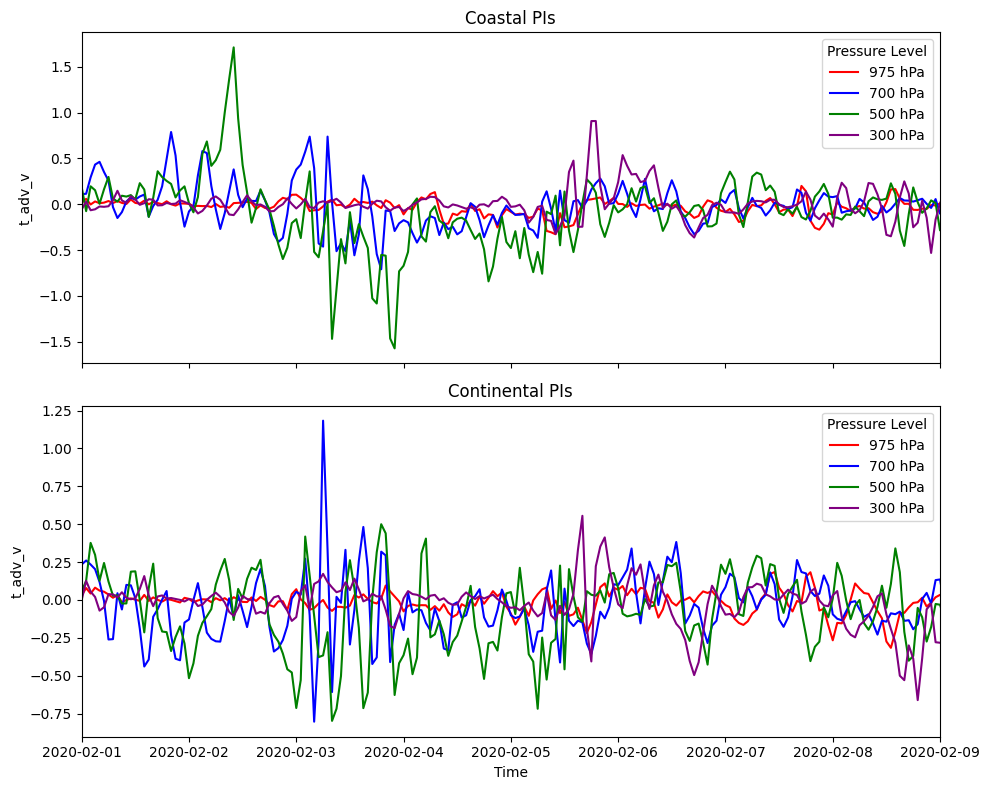

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Coastal point ---
lat1, lon1 = -48.29, -75.50
ds_sel1 = ds.sel(latitude=lat1, longitude=lon1, method='nearest')
da1 = ds_sel1['t_adv_v'].sel(pressure_level=[975, 700, 500, 300])

# --- Continental point ---
lat2, lon2 = -48.81, -73.51
ds_sel2 = ds.sel(latitude=lat2, longitude=lon2, method='nearest')
da2 = ds_sel2['t_adv_v'].sel(pressure_level=[975, 700, 500, 300])

# --- Subplots ---
fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)

levels = [975, 700, 500, 300]

# ✅ Define clear, distinct colors
color_dict = {
    975: 'red',
    700: 'blue',
    500: 'green',
    300: 'purple'
}

# --- Coastal ---
for p in levels:
    axes[0].plot(
        da1.valid_time,
        da1.sel(pressure_level=p),
        color=color_dict[p],
        label=f'{p} hPa'
    )

axes[0].set_title('Coastal PIs')
axes[0].set_ylabel('t_adv_v')
axes[0].legend(title='Pressure Level')

# --- Continental ---
for p in levels:
    axes[1].plot(
        da2.valid_time,
        da2.sel(pressure_level=p),
        color=color_dict[p],  # same color = same level
        label=f'{p} hPa'
    )

axes[1].set_title('Continental PIs')
axes[1].set_ylabel('t_adv_v')
axes[1].set_xlabel('Time')
axes[1].legend(title='Pressure Level')

# --- Limits ---
for ax in axes:
    ax.set_xlim(pd.to_datetime('2020-02-01'), pd.to_datetime('2020-02-09'))

plt.tight_layout()
plt.show()

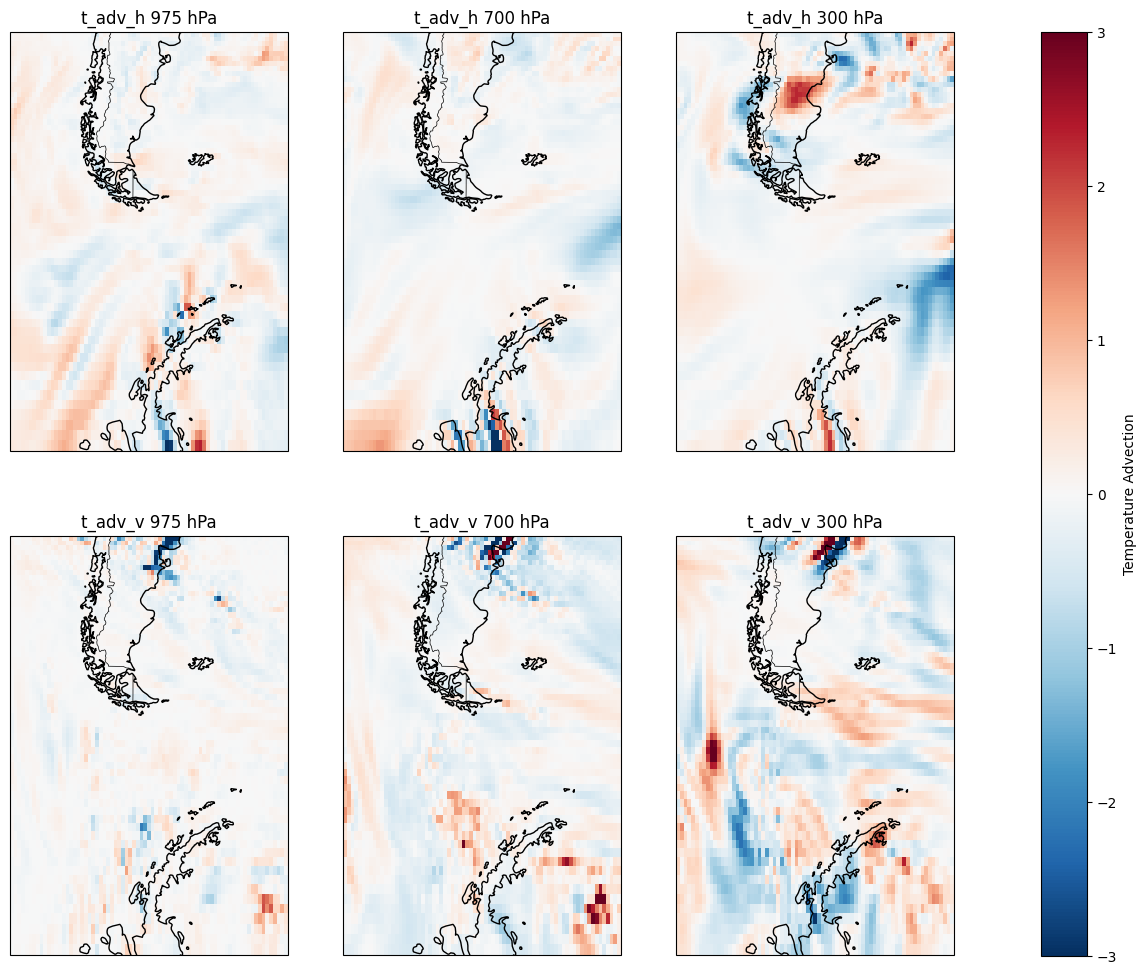

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

levels = [975, 700, 300]

# --- Select data ---
ds_sel = ds.sel(valid_time='2020-02-07T13')

da_h = ds_sel['t_adv_h'].sel(pressure_level=levels)
da_v = ds_sel['t_adv_v'].sel(pressure_level=levels)  # ⚠️ adjust name if needed

# --- Figure ---
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 12),
    subplot_kw={'projection': ccrs.Mercator()}
)

# --- Plot ---
for j, p in enumerate(levels):

    # --- Row 1: Horizontal ---
    ax = axes[0, j]
    m1 = da_h.sel(pressure_level=p).plot(
        ax=ax,
        x='longitude',
        y='latitude',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        vmin=-3, vmax=3,
        cmap='RdBu_r'
    )
    ax.set_title(f't_adv_h {p} hPa')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # --- Row 2: Vertical ---
    ax = axes[1, j]
    m2 = da_v.sel(pressure_level=p).plot(
        ax=ax,
        x='longitude',
        y='latitude',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        vmin=-3, vmax=3,
        cmap='RdBu_r'
    )
    ax.set_title(f't_adv_v {p} hPa')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# --- Row labels (cleaner than titles everywhere) ---
axes[0, 0].set_ylabel('Horizontal\nLatitude')
axes[1, 0].set_ylabel('Vertical\nLatitude')

# --- Shared colorbar ---
cbar = plt.colorbar(
    m1,
    ax=axes,
    orientation='vertical',
    fraction=0.05,
    pad=0.08
)
cbar.set_label('Temperature Advection')
